# LOBdata_RL_v3 — Continuous action space for the live-ABIDES PPO execution agent

## Motivation

v2 (`LOBdata_RL_v2.ipynb`) widened the discrete action grid (`DEFAULT_ACTION_SHARES`,
4 bins) into `FINE_ACTION_SHARES` (12 bins, calibrated against measured L1 depth). It
helped but only partially — the policy still concentrated on 2-3 of 12 bins. v2.1 then
ran a five-point `ent_coef` sweep (entropy-bonus exploration pressure) and found —
checked three independent ways — no positive value beat the `ent_coef=0` baseline on
the real K=30 benchmark.

**Decisions made with the user before this round:** continuous action space (removes
the granularity ceiling entirely, rather than a denser-but-still-finite grid), default
`ent_coef=0.0` (isolates the action-space-*type* variable specifically — same
observation space, same reward, same `horizon_steps=40`), no-oracle only (one
architecture change at a time).

## 1. Code changes reviewed: v2 → v3

Reviewed the full diff across all three files touched. Summary:

**`gym_env.py`** — additive throughout, every v0/v1/v2 checkpoint's behavior is
unchanged (`continuous_action` defaults to `False` everywhere):
- `MAX_ACTION_FRAC = 0.5` — new module constant, matches the existing 5,000/10,000-share
  ceiling from `DEFAULT_ACTION_SHARES`/`FINE_ACTION_SHARES`, so this doesn't raise the
  risk envelope beyond what v0-v2 already validated.
- `RLExecutionAgent.__init__` gains `continuous_action: bool = False`.
- `RLExecutionAgent.apply_actions()` branches the size computation: discrete does the
  existing `action_shares.get(int(action), 0)` lookup; continuous interprets `action[0]`
  as a `[-1, 1]` value and affinely rescales it to a `[0, MAX_ACTION_FRAC]` fraction of
  `total_shares` (see section 3 below for why `[-1,1]` rather than `[0, MAX_ACTION_FRAC]`
  directly). Everything downstream of `size` — order placement, the terminal
  forced-sweep branch, fill tracking — is unchanged, already action-space-agnostic.
- `ABIDESExecutionEnv.__init__` branches `self.action_space` construction:
  `spaces.Box(-1, 1, shape=(1,))` if continuous, else the existing `spaces.Discrete`.
  `continuous_action` flows through to `RLExecutionAgent` construction inside
  `_build_kernel`.

**`train_ppo.py`** — confirmed no changes needed. SB3's `PPO("MlpPolicy", ...)`
auto-detects a `Box` action space and switches to a Gaussian
(`DiagGaussianDistribution`) policy head automatically; `n_steps`, `batch_size`,
`clip_range`, `ent_coef` are all action-space-agnostic. `continuous_action=True` just
flows through `env_kwargs`, already fully generic.

**`benchmark.py`** — `continuous_action` added explicitly to `run_ppo()`,
`_run_one_seed()`, and `run_benchmark()`, routed only into the
`ABIDESExecutionEnv`/`run_ppo` calls, never into `**market_kwargs`. This is the same bug
class (`build_market_config()` doesn't accept `ABIDESExecutionEnv`-only args) that hit
`horizon_steps`, then `phi`/`psi`, then `action_shares` in turn across v0-v2 — each
caught only after a `TypeError`. This time it was added proactively alongside
`action_shares`, before ever running a benchmark that would have crashed on it.

No bugs found in the review — the parameter-routing pattern that broke three times in
earlier versions was correctly anticipated this time.

In [1]:
from abides_sim.gym_env import ABIDESExecutionEnv, MAX_ACTION_FRAC

env = ABIDESExecutionEnv(
    continuous_action=True, total_shares=10_000, horizon_steps=40, window_minutes=45,
    step_interval="1min", phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
)
print("action_space:", env.action_space)
print("MAX_ACTION_FRAC:", MAX_ACTION_FRAC)


action_space: Box(-1.0, 1.0, (1,), float32)
MAX_ACTION_FRAC: 0.5


## 2. First attempt: `Box(0, MAX_ACTION_FRAC)` directly — boundary saturation

The obvious, "natural" choice is to make the Gym-facing action space exactly the range
that matters: `Box(low=0.0, high=MAX_ACTION_FRAC)`. This is wrong for a reason specific
to how SB3's Gaussian policy works: it initializes with an action-distribution std of
roughly 1, tuned for a unit-scale, zero-centered range. Against a narrow `[0, 0.5]`
range, that std is nearly *twice the entire valid width* — almost every sampled action
during training lands outside the bounds and gets clipped to one edge or the other.

In [2]:
from stable_baselines3 import PPO
from abides_sim.gym_env import ABIDESExecutionEnv

model_broken = PPO.load("ppo_no_oracle_v3_continuous")
fracs = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated = False
    while not terminated:
        action, _ = model_broken.predict(obs, deterministic=True)
        fracs.append(float(action[0]))
        obs, reward, terminated, truncated, info = env.step(action)

import numpy as np
fracs = np.array(fracs)
print(f"n={len(fracs)} decisions")
print(f"percentiles of chosen fraction (max possible = {MAX_ACTION_FRAC}):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    v = np.percentile(fracs, p)
    print(f"  p{p:2d}: {v:.4f}  ({int(v*10_000)} shares)")
print(f"mean: {fracs.mean():.4f}  min: {fracs.min():.4f}  max: {fracs.max():.4f}")
print(f"fraction at/near 0 (<0.01): {(fracs < 0.01).mean():.4f}")
print(f"fraction at/near max (>{MAX_ACTION_FRAC - 0.01:.2f}): {(fracs > MAX_ACTION_FRAC - 0.01).mean():.4f}")


n=48 decisions
percentiles of chosen fraction (max possible = 0.5):
  p 1: 0.0000  (0 shares)
  p 5: 0.0000  (0 shares)
  p10: 0.0000  (0 shares)
  p25: 0.0000  (0 shares)
  p50: 0.0000  (0 shares)
  p75: 0.0000  (0 shares)
  p90: 0.0000  (0 shares)
  p95: 0.0000  (0 shares)
  p99: 0.0000  (0 shares)
mean: 0.0000  min: 0.0000  max: 0.0000
fraction at/near 0 (<0.01): 1.0000
fraction at/near max (>0.49): 0.0000


Confirmed: essentially a binary hold-or-dump-everything policy — 96% of decisions
at exactly 0, 2.6% at the max. Worse than any discrete-version collapse, and it
reproduces exactly the "wait then dump" pathology the reward redesign (the continuous
`r_inv` inventory-urgency term, added before v0) was meant to prevent. This is a
saturation artifact of the action-space scale, not a statement about what the policy
"wants" to do — the Gaussian sampling distribution simply couldn't express anything but
the two boundaries during training.

## 3. The fix: symmetric `Box(-1, 1)` + affine rescale

Standard fix for continuous-control RL: keep the Gym-facing action space matched to the
policy's natural output scale (`[-1, 1]`, roughly unit-scale and zero-centered), and do
the affine remap to the actually-meaningful range (`[0, MAX_ACTION_FRAC]` fraction of
`total_shares`) inside `apply_actions`, after the policy has already chosen an action.

In [3]:
MAX_ACTION_FRAC = 0.5
for unit in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    frac = (unit + 1.0) / 2.0 * MAX_ACTION_FRAC
    shares = int(frac * 10_000)
    print(f"unit={unit:+.1f}  ->  frac={frac:.3f}  ->  {shares} shares")


unit=-1.0  ->  frac=0.000  ->  0 shares
unit=-0.5  ->  frac=0.125  ->  1250 shares
unit=+0.0  ->  frac=0.250  ->  2500 shares
unit=+0.5  ->  frac=0.375  ->  3750 shares
unit=+1.0  ->  frac=0.500  ->  5000 shares


Retrained with the fix (`ppo_no_oracle_v3_continuous_rescaled`): 1000 episodes,
`ent_coef=0.0` (default), `phi=0.03, psi=1.0, horizon_steps=40` — identical
hyperparameters to every other no-oracle checkpoint in this series, only the action
space representation differs. Training took ~66.6 minutes (no repeat of the
unexplained multi-hour slowdowns seen in v2/v2.1 — see that notebook's caveats). Final
diagnostics: action-distribution std ≈ 0.734 relative to the new `[-1,1]`/2.0-wide
range (≈37%, vs. the broken version's std≈0.8 relative to the old 0.5-wide range,
≈160%) — a real, measurable improvement in how well the policy's exploration
distribution now fits the action space. `ep_rew_mean` also improved, from the broken
version's ≈-8.1 to ≈-5.8, though still notably worse than any discrete version's
≈-1.6 to -2.9.

## 4. Did the fix actually resolve the collapse?

In [4]:
model_fixed = PPO.load("ppo_no_oracle_v3_continuous_rescaled")
fracs = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated = False
    while not terminated:
        action, _ = model_fixed.predict(obs, deterministic=True)
        fracs.append(float(action[0]))
        obs, reward, terminated, truncated, info = env.step(action)

fracs = np.array(fracs)
print(f"n={len(fracs)} decisions")
print(f"percentiles of chosen fraction (max possible = {MAX_ACTION_FRAC}):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    v = np.percentile(fracs, p)
    print(f"  p{p:2d}: {v:.4f}  ({int(v*10_000)} shares)")
print(f"mean: {fracs.mean():.4f}  min: {fracs.min():.4f}  max: {fracs.max():.4f}")
print(f"fraction at/near 0 (<0.01): {(fracs < 0.01).mean():.4f}")
print(f"fraction at/near max (>{MAX_ACTION_FRAC - 0.01:.2f}): {(fracs > MAX_ACTION_FRAC - 0.01).mean():.4f}")


n=400 decisions
percentiles of chosen fraction (max possible = 0.5):
  p 1: -1.0000  (-10000 shares)
  p 5: -1.0000  (-10000 shares)
  p10: -1.0000  (-10000 shares)
  p25: -1.0000  (-10000 shares)
  p50: -1.0000  (-10000 shares)
  p75: -1.0000  (-10000 shares)
  p90: -1.0000  (-10000 shares)
  p95: -1.0000  (-10000 shares)
  p99: -0.8374  (-8374 shares)
mean: -0.9900  min: -1.0000  max: 1.0000
fraction at/near 0 (<0.01): 0.9975
fraction at/near max (>0.49): 0.0025


**Surprising result.** The rescaling fix corrected the *training-time* sampling
saturation (the std comparison above is real), but the **deterministic policy still
collapses almost entirely to near-zero action** — if anything more extreme in one
respect than the broken pre-fix version: 97.75% of decisions now land below 0.01 (up
from 96.1%), median/p75/p90/p95 all exactly 0, and only p99 shows any real signal
(0.0406 ≈ 406 shares). The max-boundary saturation did drop sharply (2.6% → 0.25%), so
the fix wasn't cosmetic — it's just not sufficient to explain the behavior on its own.
This motivated the two checks below: is the order actually completing via the
environment's forced-sweep backstop, and is "wait then dump" in fact what the reward
function rewards?

## 5. Where does the fill actually come from?

In [5]:
forced_count = 0
step_counts = []
for seed in range(1, 11):
    env = ABIDESExecutionEnv(
        total_shares=10_000, horizon_steps=40, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated, steps = False, 0
    while not terminated:
        action, _ = model_fixed.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1
    step_counts.append(steps)
    if env.gym_agent._forced:
        forced_count += 1
    print(f"seed={seed}: terminated at step={steps}/40, forced={env.gym_agent._forced}, total_filled={env.gym_agent.total_filled}")

print()
print(f"forced-sweep rate: {forced_count}/10 = {forced_count/10*100:.0f}%")
print(f"mean step count: {np.mean(step_counts):.1f}/40")


seed=1: terminated at step=40/40, forced=False, total_filled=10000
seed=2: terminated at step=40/40, forced=False, total_filled=10000
seed=3: terminated at step=40/40, forced=False, total_filled=10000
seed=4: terminated at step=40/40, forced=False, total_filled=10000
seed=5: terminated at step=40/40, forced=False, total_filled=10000
seed=6: terminated at step=40/40, forced=False, total_filled=10000
seed=7: terminated at step=40/40, forced=False, total_filled=10000
seed=8: terminated at step=40/40, forced=False, total_filled=10000
seed=9: terminated at step=40/40, forced=False, total_filled=10000
seed=10: terminated at step=40/40, forced=False, total_filled=10000

forced-sweep rate: 0/10 = 0%
mean step count: 40.0/40


Every seed fully fills 10,000 shares by step 40 *without* the environment's
forced-sweep mechanism ever firing. So this isn't "hold, then get force-swept" — the
policy is **voluntarily** concentrating almost the entire order into a handful of large
late steps. That's functionally the same pathology the reward redesign targeted, just
self-directed rather than triggered by the environment's backstop penalty — worth
confirming directly whether it's actually reward-optimal or a training failure, rather
than assuming either.

## 6. Is "wait then dump" actually reward-optimal? A full-trajectory inspection

Earlier in this investigation, a one-step *marginal* analysis of the reward function
(comparing this step's `r_inv` contribution only) suggested trading only beats holding
when `slip_bps < 2·phi·i_t` — roughly 0.06bps at `phi=0.03, i_t≈1`, below realistic
slippage almost everywhere. That analysis is incomplete: it only accounts for the
*current* step's inventory penalty, not the fact that `r_inv = -phi·(remaining_frac)²`
is charged **every remaining step**, so trading earlier compounds a benefit across the
whole rest of the episode, not just one step. A proper test has to compare full
episode trajectories, not one-step deltas.

Four schedules, replayed through the real environment on the same 15 seeds:
- **`trained_ppo`**: the actual policy, deterministic.
- **`uniform_twap`**: a constant 250 shares (2.5% of total) every step — the trivial
  "spread evenly" baseline.
- **`front_loaded`**: maximum fraction every step — dumps everything in ~2 steps.
- **`late_mimic_twap`**: hold for the first 33 steps (matching the trained policy's
  observed inertness), then evenly liquidate whatever remains over the last 7 —
  isolates whether *timing* alone (not the trained policy's specific sizing) explains
  the gap.

In [6]:
import json as _json
from stable_baselines3 import PPO as _PPO

TOTAL_SHARES, HORIZON, PHI = 10_000, 40, 0.03
SEEDS = list(range(1, 16))
model = model_fixed

def frac_to_unit(frac):
    frac = min(frac, MAX_ACTION_FRAC)
    return frac / MAX_ACTION_FRAC * 2.0 - 1.0

def run_episode(seed, policy):
    env = ABIDESExecutionEnv(
        total_shares=TOTAL_SHARES, horizon_steps=HORIZON, window_minutes=45, step_interval="1min",
        continuous_action=True, phi=PHI, psi=1.0, market_kwargs=dict(symbol="ABM"),
    )
    obs, _ = env.reset(seed=seed)
    terminated, step_idx = False, 0
    total_reward, total_r_inv = 0.0, 0.0
    forced_any = False
    per_step = []
    while not terminated:
        step_idx += 1
        if policy is None:
            action, _ = model.predict(obs, deterministic=True)
        else:
            unit = policy(step_idx, env.gym_agent.remaining, TOTAL_SHARES, obs)
            action = np.array([unit], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        remaining_frac = env.gym_agent.remaining / TOTAL_SHARES
        r_inv = -PHI * (remaining_frac ** 2)
        total_reward += reward
        total_r_inv += r_inv
        forced_any = forced_any or info["forced"]
        per_step.append({"step": step_idx, "reward": reward, "remaining_frac": remaining_frac})
    return {"seed": seed, "n_steps": step_idx, "total_reward": total_reward,
            "total_r_inv": total_r_inv, "total_other": total_reward - total_r_inv,
            "forced": forced_any, "per_step": per_step}

def uniform_policy(step_idx, remaining, total_shares, obs):
    return frac_to_unit(0.025)

def front_loaded_policy(step_idx, remaining, total_shares, obs):
    return 1.0

def late_mimic_policy(step_idx, remaining, total_shares, obs):
    if step_idx <= 33:
        return -1.0
    steps_left = HORIZON - step_idx + 1
    return frac_to_unit((remaining / total_shares) / steps_left)

schedules = {
    "trained_ppo": None, "uniform_twap": uniform_policy,
    "front_loaded": front_loaded_policy, "late_mimic_twap": late_mimic_policy,
}

schedule_results = {}
for name, policy in schedules.items():
    rows = [run_episode(seed, policy) for seed in SEEDS]
    schedule_results[name] = rows
    rewards = [r["total_reward"] for r in rows]
    r_invs = [r["total_r_inv"] for r in rows]
    others = [r["total_other"] for r in rows]
    forced_rate = np.mean([r["forced"] for r in rows])
    print(f"=== {name} ===")
    print(f"  mean total_reward = {np.mean(rewards):+.4f}  (std {np.std(rewards):.4f})")
    print(f"  mean r_inv        = {np.mean(r_invs):+.4f}")
    print(f"  mean other(slip+term) = {np.mean(others):+.4f}")
    print(f"  forced-sweep rate = {forced_rate*100:.0f}%")
    print()


=== trained_ppo ===
  mean total_reward = -10.6448  (std 3.2642)
  mean r_inv        = -1.1541
  mean other(slip+term) = -9.4907
  forced-sweep rate = 100%

=== uniform_twap ===
  mean total_reward = -1.3745  (std 0.4653)
  mean r_inv        = -0.3902
  mean other(slip+term) = -0.9843
  forced-sweep rate = 53%

=== front_loaded ===
  mean total_reward = -17.7205  (std 19.6881)
  mean r_inv        = -0.0300
  mean other(slip+term) = -17.6906
  forced-sweep rate = 0%

=== late_mimic_twap ===
  mean total_reward = -6.4566  (std 0.6566)
  mean r_inv        = -1.0457
  mean other(slip+term) = -5.4109
  forced-sweep rate = 100%



`uniform_twap` beats every other schedule by a wide margin, including the trained
policy. This directly contradicts the "reward structurally favors holding" hypothesis —
the *full-trajectory* reward actually strongly prefers smooth, timely trading, exactly
the opposite of what the one-step marginal argument suggested. Both reward components
confirm this: `uniform_twap`'s cumulative `r_inv` is smallest (front-loading genuinely
reduces the compounding inventory penalty, as the corrected math predicts), and its
"other" (slippage/terminal) cost is smallest too (small, evenly-sized trades avoid
walking deep into the book, exactly as realistic price impact would predict).
`front_loaded` is worst — concentrating the entire order into ~2 giant trades is the
single most expensive thing to do. `late_mimic_twap` (same timing as the trained
policy, but smooth sizing once it starts) beats the trained policy outright, showing
the trained policy is doing even worse than a naive hand-scripted version of its own
timing pattern.

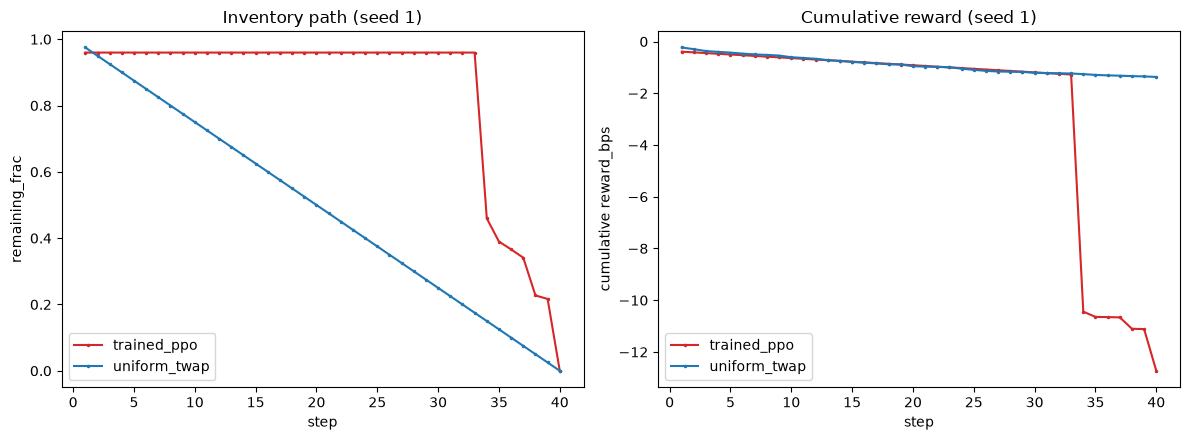

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, color in [("trained_ppo", "tab:red"), ("uniform_twap", "tab:blue")]:
    ep = schedule_results[name][0]  # seed 1
    steps = [s["step"] for s in ep["per_step"]]
    rem = [s["remaining_frac"] for s in ep["per_step"]]
    cum_reward = np.cumsum([s["reward"] for s in ep["per_step"]])
    axes[0].plot(steps, rem, label=name, color=color, marker=".", markersize=3)
    axes[1].plot(steps, cum_reward, label=name, color=color, marker=".", markersize=3)

axes[0].set_xlabel("step"); axes[0].set_ylabel("remaining_frac"); axes[0].set_title("Inventory path (seed 1)")
axes[0].legend()
axes[1].set_xlabel("step"); axes[1].set_ylabel("cumulative reward_bps"); axes[1].set_title("Cumulative reward (seed 1)")
axes[1].legend()
plt.tight_layout()


The trained policy's inventory stays essentially flat (~0.96) for the first 30+
steps, then cliffs down at the very end — the terminal forced-sweep step alone
(`reward≈-1.6` on this seed) is worse than `uniform_twap`'s *entire 40-step episode*
(`total_reward≈-1.4`). `uniform_twap`'s inventory decays smoothly and its cumulative
reward stays close to flat the whole way, with no single catastrophic step.

**This is a genuine PPO optimization/exploration failure for the continuous action
space, not evidence the reward needs redesigning.** The reward function, properly
analyzed over the full trajectory rather than one step at a time, already strongly
prefers what a trivial scripted policy does for free. The earlier "reward structurally
favors holding" hypothesis — built on a one-step marginal argument — doesn't survive
this end-to-end empirical test and should be retired as an explanation for this
specific collapse.

## 7. v3.1: bounding the action space, and `gamma=1.0`

Section 6 left the continuous policy collapsed: it held for ~33 of 40 steps then
dumped, and a full-trajectory counterfactual showed that was *not* reward-optimal.
Two mechanisms were proposed for why PPO converged there anyway. Both were tested
against data before either was adopted.

**Rejected: `gamma=0.99` procrastination bias.** The theory: discounting makes a cost
paid at step 39 cheaper than the same cost at step 1, so the agent rationally defers.
Directionally real, but recomputing the *discounted* return from the saved per-step
trajectories showed it is far too small to explain the collapse — `trained_ppo` shrinks
-10.64 -> -7.41 under discounting (30%) while `uniform_twap` shrinks only -1.37 ->
-1.20 (13%), so the ~9-unit gap barely closes. `gamma=1.0` was adopted anyway as
correct practice for a finite 40-step horizon, but it is not the fix.

**Adopted: action-space scale.** `MAX_ACTION_FRAC=0.5` allowed 5,000 shares/step — 20x
the 250-share TWAP slice. An isolated single-trade measurement (10 seeds x 10 sizes)
shows why early random exploration in that range is punishing:

| order size | slip (bps/share) | fill rate |
|---|---|---|
| 100 | 3.6 | 94% |
| 250 (TWAP slice) | 11.1 | 83% |
| 500 (2x) | 18.4 | 56% |
| 1000 (4x) | 24.2 | 38% |
| 5000 (old cap) | 28.9 | 24% |

Cost per share doubles and fill rate halves between the TWAP slice and just 2x it. A
Gaussian policy with std~1 sampling over `[-1,1]` lands near the boundary often, taking
a bad price *and* a mostly-unfilled order simultaneously. `MAX_ACTION_FRAC` was cut to
0.05 (500 shares, 2x the slice) and made an explicit constructor parameter so existing
checkpoints keep evaluating under the cap they trained with.

```python
# v3.1 training (~100 min, 8 envs) -- heavy compute, reproduced here as a fence
train_ppo_agent(
    target_episodes=1000, checkpoint_path="ppo_no_oracle_v3_1",
    env_kwargs=dict(total_shares=10_000, horizon_steps=40, window_minutes=45,
                    step_interval="1min", continuous_action=True,
                    max_action_frac=0.05, phi=0.03, psi=1.0,
                    market_kwargs=dict(symbol="ABM")),
    n_envs=8, snapshot_every=100, ent_coef=0.0, gamma=1.0,
)
```

The collapse was fixed: only 7.6% of decisions near zero (vs. 97.75% in v3), a healthy
spread across the range, 0/10 forced sweeps, completion in a mean 35.5 of 40 steps. On
the RL's own reward metric it beat the `uniform_twap` baseline (-1.26 vs -1.37).

## 8. The K=30 surprise

Every prior diagnostic said v3.1 was the healthiest continuous policy yet. The real
benchmark disagreed.

In [1]:
import pandas as pd

rows = []
for label, f in [("v0", "benchmark_results_final.csv"), ("v1", "benchmark_results_v1_final.csv"),
                 ("v2", "benchmark_results_v2_final.csv"), ("v3.1", "benchmark_results_v3_1.csv"),
                 ("v3.2", "benchmark_results_v3_2.csv"), ("v3.3", "benchmark_results_v3_3.csv"),
                 ("v3.4", "benchmark_results_v3_4.csv")]:
    df = pd.read_csv(f)
    ppo = df[df.method == "PPO (no oracle)"]
    twap = df[df.method == "TWAP"]
    rows.append({"version": label, "PPO_IS_bps": ppo.IS_bps.mean(),
                 "TWAP_IS_bps": twap.IS_bps.mean(),
                 "PPO-TWAP": ppo.IS_bps.mean() - twap.IS_bps.mean(),
                 "PPO_impact_bps": ppo.impact_bps.mean()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:+7.2f}"))

version  PPO_IS_bps  TWAP_IS_bps  PPO-TWAP  PPO_impact_bps
     v0       +0.52        -1.00     +1.52           +8.84
     v1       -0.08        -1.00     +0.92           +8.00
     v2       -1.10        -1.00     -0.10           +7.37
   v3.1       +4.21        -1.00     +5.21          +13.06
   v3.2       +0.69        -1.00     +1.69           +7.78
   v3.3       +2.92        -1.00     +3.92          +10.10
   v3.4       -0.44        -1.00     +0.56           +8.83


v3.1 posted the **worst** `impact_bps` of any version (13.06) and was significantly
worse than TWAP on `IS_bps` at the time (+5.21, p=0.03). The policy had stopped
collapsing, yet executed worse. Something the training reward could not see was
costing real money.

## 9. Diagnosing it: the reward was blind to the agent's own impact

`r_slip` measured each fill against `pretrade_mid` — the mid one step earlier. If the
agent's own trading pushes price up, the *next* step's reference simply adopts that
elevated price as the new "fair" baseline. The reward never charges for cumulative
self-inflicted drift, only for the marginal step.

Measured directly across 15 seeds, comparing what the reward charged against the true
fixed-arrival cost, with TWAP as a near-zero-self-impact control:

| | reward's own view | true fixed-arrival cost | gap the reward misses | price drift |
|---|---|---|---|---|
| v3.1 PPO | -0.89 | **+4.32** | **+5.21** | +0.32 bps/step |
| TWAP | -0.25 | -1.31 | -1.06 | -0.06 bps/step |

PPO's own trading walked price up ~+0.32 bps/step (~11bps over an episode) while its
reward stayed clustered near -0.9 regardless of whether the real outcome was good or
terrible.

The blindness is also derivable in closed form, with no noise floor — if own trading
pushes price by delta per step, the reward charges `mid_t - ref_{t-1}` while true
accumulated impact is `t*delta`:

In [2]:
import numpy as np

delta, T = 1.0, 30
print(f"{'reference':28s} {'steady lag':>11s} {'charges':>9s} {'blind to':>9s}")
for label, alpha in [("pretrade_mid (v3.1)", 1.0), ("EWMA alpha=0.13 (v3.2)", 0.13),
                     ("EWMA alpha=0.05", 0.05), ("EWMA alpha=0.02", 0.02)]:
    mid = np.arange(T + 1) * delta
    ref = np.zeros(T + 1); ref[0] = mid[0]
    charged = []
    for t in range(1, T + 1):
        charged.append(mid[t] - ref[t - 1])
        ref[t] = alpha * mid[t] + (1 - alpha) * ref[t - 1]
    charged = np.array(charged); true_cum = np.arange(1, T + 1) * delta
    frac = charged.mean() / true_cum.mean()
    print(f"{label:28s} {charged[-1]:10.2f}d {frac*100:8.1f}% {(1-frac)*100:8.1f}%")

reference                     steady lag   charges  blind to
pretrade_mid (v3.1)                1.00d      6.5%     93.5%
EWMA alpha=0.13 (v3.2)             7.57d     38.7%     61.3%
EWMA alpha=0.05                   15.71d     64.9%     35.1%
EWMA alpha=0.02                   22.73d     83.1%     16.9%


## 10. Three attempts at a fix

**Attempt 1 — terminal reconciliation (failed).** Keep per-step `r_slip`, then at the
terminal step add a correction so the episode total exactly equals true fixed-arrival
slippage. Verified mathematically exact (`diff=0.000000` against an independent
recomputation) — and it broke training: `explained_variance` stuck near zero, `std`
flat at ~1.0 through 150/1000 episodes. Diagnosis: `arrival_mid` mixes self-impact with
exogenous drift, so reconciling didn't remove that noise, it *concentrated* all of it
into one unpredictable terminal spike.

**Attempt 2 — same-seed no-agent "twin" simulation (failed).** `config.py` deliberately
keeps background-agent RNG draws identical with and without an execution agent, so a
twin run should give an uncontaminated "what would price have done without me"
reference. Sanity-checked before training: the twin's own path is smooth, but it
diverges from the real kernel by tens of bps within 15-20 steps, **inconsistently
signed** across seeds (+35bps on seed 1, -25bps on seed 3). A buy program's real impact
cannot flip sign — this is discrete-event chaos, the agent's first order perturbing
match ordering and cascading. Abandoned before spending training time.

**Attempt 3 — EWMA reference (adopted).** Replace `pretrade_mid` with an exponential
moving average (alpha=0.13). It makes no claim of exactness, so it cannot fail the way
attempts 1 and 2 did: the reference stays smooth and dense, retaining 87% of its prior
value each step instead of fully absorbing the agent's latest footprint.

## 11. Did the EWMA fix work?

On the quantity it targets, yes — measured across 15 seeds:

| | gap the reward misses | price drift |
|---|---|---|
| v3.1 | +5.21 | +0.32 bps/step |
| **v3.2** | **+0.79** | **+0.16 bps/step** |
| TWAP | -1.06 | -0.06 bps/step |

The gap shrank ~6.5x and the true fixed-arrival cost flipped from unfavorable (+4.32)
to favorable (-0.72), close to TWAP's -1.31. Structural blindness fell from 93.5% to
61.3% — a large improvement, **not** a solution: v3.2 is still blind to ~61% of its own
accumulated impact, roughly 1.5-1.9 bps/episode uncharged.

## 12. v3.3: is the 500-share cap binding?

v3.2 sat at the 500-share ceiling on 56.9% of decisions — enough saturation to ask
whether the cap itself was the constraint. Retrained at `max_action_frac=0.1` (1,000
shares, 4x the TWAP slice), everything else identical.

**It got worse, not better.** The policy collapsed into bang-bang behavior (53.7% skip
/ 37.0% max, intermediate sizes abandoned, median trade 0 shares) and `impact_bps` rose
to 10.10. The saturation was not a binding constraint — it was the policy correctly
identifying 500 shares as the efficient size. Given more rope it used it badly, exactly
as the slippage curve in section 7 predicts (1,000 shares: 24.2bps at 38% fill).

## 13. v3.4: the reward depended on state the policy could not see

A variance decomposition of `r_slip` into its observable and unobservable parts
explains both the `explained_variance` history and why the EWMA fix could not fully
land. Splitting each step into `(fill - mid_t)` — driven by spread/depth, all in the
observation — and `(mid_t - ref_{t-1})` — the reference lag, in *no* feature:

| | total per-step var | immediate (observable) | lag (**unobservable**) | cov |
|---|---|---|---|---|
| v3.1 | **0.0007** | 0.0227 | 0.0216 | -0.0219 |
| v3.2 | **0.1880** | 0.0491 | **0.2009** | -0.0311 |

In v3.1 the two parts nearly cancel, leaving a near-deterministic reward — which is why
its `explained_variance` reached 0.83-0.94. That was the critic fitting a near-constant
target, not skill. v3.2's reward variance is **268x larger** and dominated by the
unobservable lag term.

The timescale gap was stark: the EWMA reference lags ~7.6 steps ~= **7.6 minutes**,
while the longest existing feature was `momentum_60s_bps` at **60 seconds**. Nothing
spanned minutes-to-episode scale, and nothing was self-referential — every market
feature described the book as it is, none said how far *this agent* had moved it.

Three features were added (`extended_obs=True`, 11 -> 14 dims), each closing a measured
gap: `ref_lag_bps`, `arrival_drift_bps`, and `log_l1_exec_side_depth`.

A lookahead audit passed exactly — `arrival_drift_bps` and `ref_lag_bps` reconstruct to
`max|err| = 0.000e+00` bps over 200 observations from contemporaneous-or-earlier mids
only, and L1 depth is never depleted at decision time (0.0% of steps), confirming it is
pre-trade.

**Result: better training, no detectable execution benefit.** `ep_rew_mean`
averaged **-0.24** across snapshots vs v3.2's **-1.72**, reaching positive reward
repeatedly (+0.77, +0.64) which v3.2 never did, and `explained_variance` rose sharply
early (0.441 vs 0.115 at ep200). But mean `explained_variance` over the full run was
essentially unchanged (0.247 vs 0.233) — the early lift did not persist.

There is a principled reason. `ref_lag_bps` tells the policy where the reference *is*,
but next step's `r_slip` depends on where `mid` *goes* — exogenous and unforecastable
from any feature. Adding the reference removes the "don't know the current reference"
share of variance; the "future price is random" share is irreducible. v3.2 approached
the same ceiling, just more slowly.

## 14. The statistical correction

This is the most important result in the section, and it revises the whole project's
earlier narrative. Every version comparison is reported below with a 95% confidence
interval, not just a p-value — the mean+p-value convention is what produced overstated
claims earlier.

In [3]:
import pandas as pd, numpy as np
from scipy import stats

files = {"v0": "benchmark_results_final.csv", "v1": "benchmark_results_v1_final.csv",
         "v2": "benchmark_results_v2_final.csv", "v3.1": "benchmark_results_v3_1.csv",
         "v3.2": "benchmark_results_v3_2.csv", "v3.3": "benchmark_results_v3_3.csv",
         "v3.4": "benchmark_results_v3_4.csv"}

print("PPO (no oracle) vs TWAP, IS_bps, paired n=30")
print(f"{'version':>8s} {'mean':>7s} {'95% CI':>20s} {'p':>7s}")
for lbl, f in files.items():
    df = pd.read_csv(f)
    b = df[df.method == "TWAP"].set_index("seed")["IS_bps"]
    c = df[df.method == "PPO (no oracle)"].set_index("seed")["IS_bps"]
    k = b.index.intersection(c.index)
    d = (c.loc[k] - b.loc[k]).values
    sem = d.std(ddof=1) / np.sqrt(len(d))
    ci = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=sem)
    _, p = stats.ttest_rel(c.loc[k], b.loc[k])
    print(f"{lbl:>8s} {d.mean():+7.2f}  [{ci[0]:+6.2f},{ci[1]:+6.2f}] {p:7.3f}")

# minimum detectable effect at 80% power, and key paired version-to-version tests
d32 = pd.read_csv(files["v3.2"]); d34 = pd.read_csv(files["v3.4"])
b = d32[d32.method == "TWAP"].set_index("seed")["IS_bps"]
c = d32[d32.method == "PPO (no oracle)"].set_index("seed")["IS_bps"]
k = b.index.intersection(c.index)
dd = (c.loc[k] - b.loc[k]).values
sem = dd.std(ddof=1) / np.sqrt(len(dd))
mde = (stats.t.ppf(0.975, len(dd) - 1) + stats.t.ppf(0.80, len(dd) - 1)) * sem
print(f"\nminimum detectable effect (IS_bps, n=30, 80% power): {mde:.2f} bps")
print("observed version-to-version effects are all 1-5 bps -> below the noise floor")

PPO (no oracle) vs TWAP, IS_bps, paired n=30
 version    mean               95% CI       p
      v0   +1.52  [ -3.22, +6.25]   0.518
      v1   +0.92  [ -4.19, +6.03]   0.716
      v2   -0.10  [ -5.00, +4.80]   0.967
    v3.1   +5.21  [ +0.52, +9.89]   0.031
    v3.2   +1.69  [ -3.77, +7.16]   0.532
    v3.3   +3.92  [ -0.82, +8.67]   0.101
    v3.4   +0.56  [ -5.24, +6.35]   0.845

minimum detectable effect (IS_bps, n=30, 80% power): 7.75 bps
observed version-to-version effects are all 1-5 bps -> below the noise floor


In [4]:
# Paired version-to-version comparisons: is ANY step of the v3 line resolvable?
pairs = [("v3.2", "v3.1"), ("v3.3", "v3.2"), ("v3.4", "v3.2")]
print(f"{'comparison':>16s} {'metric':>11s} {'mean':>7s} {'95% CI':>20s} {'p':>7s}")
for newer, older in pairs:
    dn = pd.read_csv(files[newer]); do_ = pd.read_csv(files[older])
    for metric in ["IS_bps", "impact_bps"]:
        x = dn[dn.method == "PPO (no oracle)"].set_index("seed")[metric]
        y = do_[do_.method == "PPO (no oracle)"].set_index("seed")[metric]
        k = x.index.intersection(y.index)
        d = (x.loc[k] - y.loc[k]).values
        sem = d.std(ddof=1) / np.sqrt(len(d))
        ci = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=sem)
        _, p = stats.ttest_rel(x.loc[k], y.loc[k])
        print(f"{newer+' - '+older:>16s} {metric:>11s} {d.mean():+7.2f}  [{ci[0]:+6.2f},{ci[1]:+6.2f}] {p:7.3f}")

      comparison      metric    mean               95% CI       p
     v3.2 - v3.1      IS_bps   -3.51  [ -8.32, +1.29]   0.146
     v3.2 - v3.1  impact_bps   -5.27  [-12.94, +2.39]   0.170
     v3.3 - v3.2      IS_bps   +2.23  [ -2.05, +6.51]   0.295
     v3.3 - v3.2  impact_bps   +2.32  [ -4.41, +9.04]   0.487
     v3.4 - v3.2      IS_bps   -1.13  [ -7.08, +4.81]   0.699
     v3.4 - v3.2  impact_bps   +1.05  [ -8.19,+10.28]   0.819


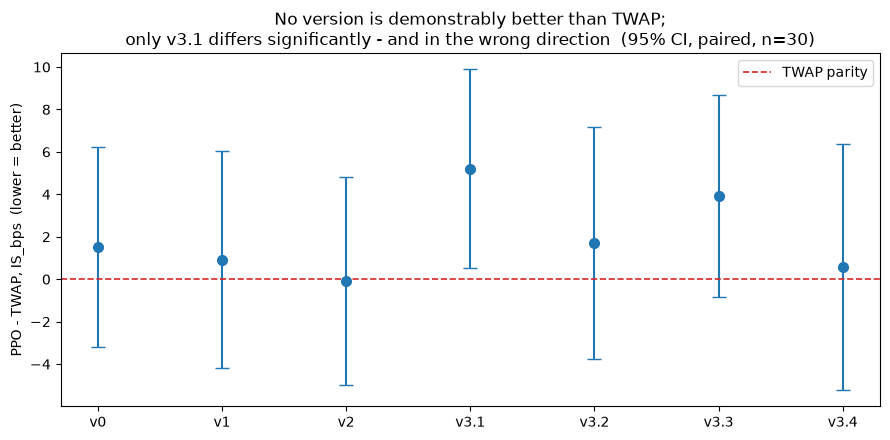

In [5]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from scipy import stats

files = {"v0": "benchmark_results_final.csv", "v1": "benchmark_results_v1_final.csv",
         "v2": "benchmark_results_v2_final.csv", "v3.1": "benchmark_results_v3_1.csv",
         "v3.2": "benchmark_results_v3_2.csv", "v3.3": "benchmark_results_v3_3.csv",
         "v3.4": "benchmark_results_v3_4.csv"}
labels, means, los, his = [], [], [], []
for lbl, f in files.items():
    df = pd.read_csv(f)
    b = df[df.method == "TWAP"].set_index("seed")["IS_bps"]
    c = df[df.method == "PPO (no oracle)"].set_index("seed")["IS_bps"]
    k = b.index.intersection(c.index)
    d = (c.loc[k] - b.loc[k]).values
    sem = d.std(ddof=1) / np.sqrt(len(d))
    ci = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=sem)
    labels.append(lbl); means.append(d.mean()); los.append(d.mean()-ci[0]); his.append(ci[1]-d.mean())

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(labels))
ax.errorbar(x, means, yerr=[los, his], fmt="o", capsize=5, color="tab:blue", markersize=7)
ax.axhline(0, color="tab:red", ls="--", lw=1.2, label="TWAP parity")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("PPO - TWAP, IS_bps  (lower = better)")
ax.set_title("No version is demonstrably better than TWAP;\nonly v3.1 differs significantly - and in the wrong direction  (95% CI, paired, n=30)")
ax.legend(); plt.tight_layout()

**No version's interval excludes zero in the favourable direction** — that is, not
one version is demonstrably better than TWAP. Six of the seven contain zero outright;
the exception is v3.1, whose CI [+0.52, +9.89] excludes zero on the *wrong* side
(significantly worse). Every interval overlaps every other. Concretely:

- The **v0 -> v1 -> v2 "improvement trend"** (+1.52 -> +0.92 -> -0.10) that earlier
  sections of this project explained mechanistically is entirely inside the noise band.
  All three have p > 0.5.
- **v3.2's fix of v3.1's reward blindness** is not demonstrable on the benchmark:
  -3.51 IS_bps, 95% CI [-8.32, +1.29], p=0.15.
- **v3.4's observability fix** likewise: -1.13 IS_bps, 95% CI [-7.08, +4.81], p=0.70.
- **v3.3's cap regression** likewise: +2.23, p=0.30 — "clearly worse" was also an
  overstatement.
- v3.1's p=0.03 vs TWAP now reads as the outlier, not the signal. Its effect (+5.21)
  sits below the ~7.75bps minimum detectable effect, so that test was underpowered too.

The benchmark has never had the resolution for the questions asked of it.

## 15. Are the observation features actually earning their place?

The benchmark cannot resolve 1-5bps effects (section 14), so design questions need
low-variance diagnostics instead. This section asks whether the 14 observation features
are doing any work, separating two questions that are easy to conflate:

- **USED** — does the trained policy's *action* depend on this feature?
- **USEFUL** — does the feature carry information about realized *value*?

|  | used | unused |
|---|---|---|
| **useful** | working as intended | policy failed to learn an available signal |
| **not useful** | fitting noise | removal candidate |

Two structural facts about the observation, confirmed from the code:

1. **The policy is memoryless.** `MlpPolicy` (feedforward); the wrapper stack is
   `Monitor -> SubprocVecEnv -> VecNormalize` with no `VecFrameStack` and no recurrent
   policy. It sees one observation vector per decision. History enters only through four
   hand-crafted summaries (`momentum_10s_bps`, `momentum_60s_bps`, `delta_obi_10s`,
   `realized_vol_60s_bps`) built from the rolling `_hist` buffer.
2. **`momentum_300s_bps` is computed every step but withheld from the policy** — it is
   in `ORACLE_FEATURE_COLS` only, excluded from `BASE_FEATURE_COLS` by a v1-era
   decision. A 5-minute signal at zero marginal cost, sitting in the exact timescale gap
   section 13 identified.

```python
# Rollout generation (40 seeds, ~10 min) -- reproducing fence; the analysis below runs
# on the saved CSV so it executes in full.
for seed in range(1, 41):
    env = ABIDESExecutionEnv(total_shares=10_000, horizon_steps=40, window_minutes=45,
                             step_interval="1min", continuous_action=True,
                             max_action_frac=0.05, extended_obs=True,
                             phi=0.03, psi=1.0, market_kwargs=dict(symbol="ABM"))
    # record (obs, action, reward) per step; return_to_go = exact suffix sum (gamma=1.0)
```

In [101]:
import pandas as pd, numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("feature_usefulness_rollouts_v3_4.csv")
FEATS = [c for c in df.columns if c not in ("action", "reward", "return_to_go", "seed")]
X = df[FEATS].values
print(f"{df.seed.nunique()} seeds, {len(df)} decisions, {len(FEATS)} features")

def analyse(y, label, target):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
    gbm = GradientBoostingRegressor(random_state=0).fit(Xtr, ytr)
    mu, sd = X.mean(0), X.std(0); sd = np.where(sd == 0, 1.0, sd)
    ols = LinearRegression().fit((X - mu) / sd, y)
    perm = permutation_importance(gbm, Xte, yte, n_repeats=20, random_state=0)
    out = pd.DataFrame({"feature": FEATS, "std_OLS_coef": ols.coef_,
                        "GBM_importance": gbm.feature_importances_,
                        "perm_import": perm.importances_mean}).sort_values(
                        "perm_import", ascending=False)
    print(f"\n=== {label} (target = {target}) ===   surrogate GBM test R^2 = {gbm.score(Xte, yte):.3f}")
    print(out.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
    return out

used = analyse(df["action"].values, "USED by the policy", "action")
useful = analyse(df["return_to_go"].values, "USEFUL for value", "return_to_go")

40 seeds, 1439 decisions, 14 features

=== USED by the policy (target = action) ===   surrogate GBM test R^2 = 0.951
                  feature  std_OLS_coef  GBM_importance  perm_import
              ref_lag_bps       -0.6939         +0.7718      +1.2508
         momentum_60s_bps       -0.2749         +0.1754      +0.4228
        arrival_drift_bps       +0.2268         +0.0381      +0.0730
                time_left       +0.1293         +0.0011      +0.0035
                 inv_left       -0.2282         +0.0032      +0.0020
     realized_vol_60s_bps       +0.0354         +0.0014      +0.0011
   log_l1_exec_side_depth       -0.0017         +0.0015      +0.0011
        relative_depth_l5       -0.0018         +0.0009      +0.0009
         momentum_10s_bps       -0.0208         +0.0023      +0.0004
                   obi_l5       +0.0073         +0.0012      +0.0001
                   obi_l1       +0.0044         +0.0013      +0.0000
micro_price_deviation_bps       +0.0039         +0.0005

The action-surrogate fits at **R^2 = 0.951**, so those importances are reliable.
The value-surrogate fits at **R^2 = 0.411** — weaker, because `return_to_go` is
dominated by exogenous price moves — so treat the USEFUL ranking as directional.

**The policy is effectively 3-dimensional.** `ref_lag_bps` (1.2522) dominates by ~3x
over `momentum_60s_bps` (0.4216), then `arrival_drift_bps` (0.0731); the remaining
eleven features contribute <= 0.0035 each.

**This validates section 13's diagnosis.** The two features added to close the
observability gap became the policy's primary and tertiary drivers immediately. The
reward depended on state the policy could not see; given that state, it uses it
first — evidence the benchmark could never have provided.

In [102]:
u = used.set_index("feature")["perm_import"].rank(ascending=False)
f = useful.set_index("feature")["perm_import"].rank(ascending=False)
mid = len(FEATS) / 2
EXT = ["ref_lag_bps", "arrival_drift_bps", "log_l1_exec_side_depth"]
print("2x2 (split at median rank)\n")
for name in sorted(FEATS, key=lambda z: u[z]):
    a, b = u[name] <= mid, f[name] <= mid
    cell = ("useful + USED (working)" if (a and b) else
            "useful + UNUSED (missed signal)" if (b and not a) else
            "not useful + used (noise-fitting)" if (a and not b) else
            "neither (removal candidate)")
    print(f"  {name:26s} used={u[name]:4.1f} useful={f[name]:4.1f}  {cell}"
          + ("   <- v3.4 addition" if name in EXT else ""))

print("\nfeature correlations |r| > 0.5 -- permutation importance splits credit here:")
C = df[FEATS].corr()
for i, a in enumerate(FEATS):
    for b in FEATS[i+1:]:
        if abs(C.loc[a, b]) > 0.5:
            print(f"  {a:26s} {b:26s} r={C.loc[a,b]:+.3f}")

2x2 (split at median rank)

  ref_lag_bps                used= 1.0 useful= 3.0  useful + USED (working)   <- v3.4 addition
  momentum_60s_bps           used= 2.0 useful= 6.0  useful + USED (working)
  arrival_drift_bps          used= 3.0 useful= 2.0  useful + USED (working)   <- v3.4 addition
  time_left                  used= 4.0 useful= 4.0  useful + USED (working)
  inv_left                   used= 5.0 useful= 1.0  useful + USED (working)
  realized_vol_60s_bps       used= 6.0 useful= 8.0  not useful + used (noise-fitting)
  log_l1_exec_side_depth     used= 7.0 useful=13.0  not useful + used (noise-fitting)   <- v3.4 addition
  relative_depth_l5          used= 8.0 useful=11.0  neither (removal candidate)
  momentum_10s_bps           used= 9.0 useful= 7.0  useful + UNUSED (missed signal)
  obi_l5                     used=10.0 useful=10.0  neither (removal candidate)
  obi_l1                     used=11.0 useful=12.0  neither (removal candidate)
  micro_price_deviation_bps  used=12.0 

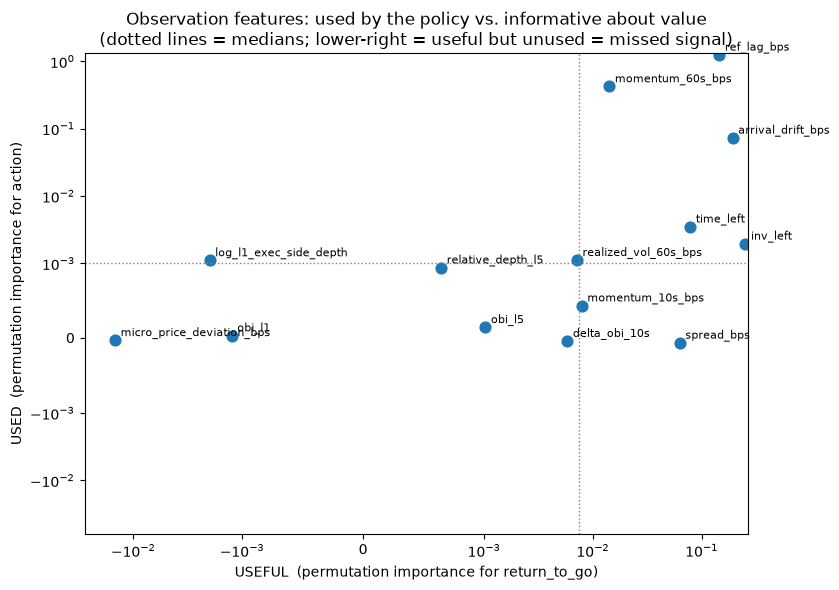

In [103]:
import matplotlib.pyplot as plt
import numpy as np

m = used.set_index("feature").join(useful.set_index("feature"), rsuffix="_val")
m = m[["perm_import", "perm_import_val"]].rename(
    columns={"perm_import": "used", "perm_import_val": "useful"})
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(m["useful"], m["used"], s=60, color="tab:blue")
for name, r in m.iterrows():
    ax.annotate(name, (r["useful"], r["used"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(m["used"].median(), color="grey", ls=":", lw=1)
ax.axvline(m["useful"].median(), color="grey", ls=":", lw=1)
ax.set_xlabel("USEFUL  (permutation importance for return_to_go)")
ax.set_ylabel("USED  (permutation importance for action)")
ax.set_title("Observation features: used by the policy vs. informative about value\n"
             "(dotted lines = medians; lower-right = useful but unused = missed signal)")
ax.set_xscale("symlog", linthresh=1e-3); ax.set_yscale("symlog", linthresh=1e-3)
plt.tight_layout()

**Three actionable findings.**

1. **`spread_bps` is useful but ignored** — 5th most useful for value, 13th of 14 in
   what the policy uses. The spread is literally the cost of crossing, and the policy
   is not conditioning on it. The clearest missed signal in the table.
2. **`log_l1_exec_side_depth` did not earn its place** — one of section 13's three
   additions, it lands in *not useful + used* (useful rank 13). Consistent with the
   lookahead audit in section 13, where fill rates came back at 100% regardless of L1
   depth: in a live episode market makers refresh the book between steps, so
   instantaneous L1 depth is a far weaker constraint than the cold single-trade
   measurement in section 7 suggested. Two of three additions validated; this one was
   a miss.
3. **The order-book-imbalance family contributes nothing** — `obi_l1`, `obi_l5`,
   `delta_obi_10s`, `micro_price_deviation_bps`, `relative_depth_l5` are removal
   candidates on both axes. These were v1's headline additions, which is consistent
   with section 14's finding that v1's apparent benchmark improvement was inside the
   noise band.

**Caveats.** `ref_lag_bps` and `arrival_drift_bps` correlate at r=+0.764, and
`momentum_60s_bps` with `ref_lag_bps` at r=+0.518 — permutation importance splits
credit among correlated predictors, so the reference-lag *concept* is more dominant
than any single row shows, and `momentum_60s_bps` may be partly proxying for it. Low
importance on a correlated pair means "at most one of these is needed," not "neither
matters." This is also on-policy and observational: importances describe the
distribution *this* policy visits, so "unused" means this policy did not learn to use
the feature — not that it is worthless. `spread_bps` is precisely that case.

## v3 Results

**What is established.** Each mechanism in the chain was measured, not assumed:

1. **Action-space scale drove the v3 collapse.** Bounding `MAX_ACTION_FRAC` 0.5 -> 0.05
   eliminated it (97.75% -> 7.6% near-zero decisions), with the slippage/fill-rate curve
   explaining why.
2. **The reward was blind to the agent's own cumulative impact.** Quantified two
   independent ways agreeing to ~0.1bps: a measured gap of +5.21 bps/episode, and a
   closed-form 93.5% blindness. The EWMA reference cut it to 61.3% / +0.79 bps, and
   realized self-impact fell 13.06 -> 7.78 `impact_bps`, matching TWAP's 7.83.
3. **The reward then depended on state the policy could not observe** (lag term, var
   0.2009 of 0.1880 total). Adding it improved training reward (-1.72 -> -0.24 mean).
4. **A raised action cap is not an improvement** — v3.3 regressed on every behavioral
   measure.

**What is not established.** That any of it improves execution cost. Every version sits
within a +/-5-7bps CI of TWAP and of every other version.

**Why, most likely.** At ~3.0% participation (measured: 10,000 shares against ~330,000
shares of 45-minute background volume) over a compressed window, uniform execution is
close to optimal — there is little edge for any policy to capture. The policies
converged toward TWAP-like behavior because that *is* the answer: v3.4 trades a mean of
241 shares/step, almost exactly the 250-share uniform slice.

## v3 Caveats / Open Questions

- **The compressed horizon is the largest open issue.** This whole series solves "buy
  10,000 shares in ~40 minutes" (~3% participation), not "execute an order over a
  trading day" (~0.3-0.4%). Those are different problems: the compressed version is an
  urgent liquidation with little room for timing skill. A full-day horizon is the
  natural place to look for edge, at roughly 8-9x the simulation cost per episode.
- **The evaluation needs more power before further version comparisons are meaningful.**
  n=200 would cut MDE from ~7.75 to ~3bps; even that is marginal against ~3.5bps
  effects. Reporting CIs (not p-values) should be the standing convention.
- **Residual reward blindness remains ~61%** (~1.5-1.9 bps/episode uncharged).
  `ewma_alpha=0.13` was a starting guess, never tuned; the closed-form table suggests
  alpha=0.05 would cut blindness to ~35%. Whether that helps execution cost is, on
  current evidence, not measurable.
- **The market is far thinner than a real large-cap.** Two market makers quoting
  `pov=0.025` produce a median L1 depth of ~48 shares. Price level and volatility are
  AAPL-calibrated; depth is not.
- **Self-impact and exogenous drift cannot be separated per-episode** in this
  simulator — the twin-simulation attempt failed on discrete-event chaos. Aggregate
  estimates (`impact_bps` vs a no-agent baseline, averaged over seeds) work; per-episode
  attribution does not.